## **Innomatics Research Labs Online Hackathon** 

Welcome to this technical notebook, created as part of the **Technical Evaluation Hackathon** organized by **Innomatics Research Labs**.  


This challenge simulates a real-world data engineering and analytics workflow.  
Participants are provided with three datasets, each in a different format, representing data from independent systems:

- **orders.csv** — Transactional order data  
- **users.json** — User master data  
- **restaurants.sql** — Restaurant master data  

---

**Objective of This Notebook**

This notebook documents the complete process of building a unified, analysis-ready dataset from heterogeneous sources. The workflow includes:

- **1. Loading the data**
Reading CSV, JSON, and SQL files  and Inspecting and validating schema consistency  
- **2. Cleaning and preparing the data**
Converting data types , Handling missing values, Standardizing key fields  
- **3. Merging the datasets** 
- **4. Creating the final dataset**
  
---

- **Analysis Goals**

Using the unified dataset, this notebook explores key analytical questions such as:

- **Order trends over time**  
- **User behavior patterns**  
- **City-wise and cuisine-wise performance**  
- **Impact of membership tiers (Gold vs Regular)**  
- **Revenue distribution and seasonality**

This final dataset serves as the **single source of truth** for all insights and visualizations produced during the hackathon.

---


In [ ]:
# packages import

import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

### Data Loading

In [54]:
# Loading orders data from CSV file

orders = pd.read_csv('data/orders.csv')
orders.head()


,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name
0,1,2508,450,18-02-2023,842.97,New Foods Chinese
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian


In [ ]:
# Checking for missing values in the orders DataFrame
orders.isna().sum()

order_id           0
user_id            0
restaurant_id      0
order_date         0
total_amount       0
restaurant_name    0
dtype: int64

In [ ]:
# Getting the shape of the orders DataFrame
orders.shape

(10000, 6)

In [55]:
# Data Loading from JSON file

with open("data/users.json", "r", encoding="utf-8") as f:
    users = json.load(f)
users = pd.DataFrame(users)
users.head()

,user_id,name,city,membership
0,1,User_1,Chennai,Regular
1,2,User_2,Pune,Gold
2,3,User_3,Bangalore,Gold
3,4,User_4,Bangalore,Regular
4,5,User_5,Pune,Gold


In [ ]:
# checking missing values
users.isna().sum()

user_id       0
name          0
city          0
membership    0
dtype: int64

In [ ]:
# getting shape of user dataframe
users.shape

(3000, 4)

In [ ]:
# Data Loading from SQLite database
conn = sqlite3.connect("restaurants.db")
cursor = conn.cursor()

# excuting sql script to create table and insert data
with open("data/restaurants.sql", "r", encoding="utf-8") as f:
    sql_script = f.read()

cursor.executescript(sql_script)
conn.commit()

# fetching data from restaurants table
cursor.execute("SELECT * FROM restaurants")
rows = cursor.fetchall()

restaurants = pd.read_sql_query("SELECT * FROM restaurants", conn)

conn.close()

restaurants.head()

,restaurant_id,restaurant_name,cuisine,rating
0,1,Restaurant_1,Chinese,4.8
1,2,Restaurant_2,Indian,4.1
2,3,Restaurant_3,Mexican,4.3
3,4,Restaurant_4,Chinese,4.1
4,5,Restaurant_5,Chinese,4.8


In [ ]:
# checking missing values in restaurants dataframe
restaurants.isna().sum()

restaurant_id      0
restaurant_name    0
cuisine            0
rating             0
dtype: int64

In [ ]:
# getting shape of restaurants dataframe
restaurants.shape

(500, 4)

### Merge Datasets

In [92]:
# Perform joins orders with users on user_id:
orders_users = orders.merge(users, on="user_id", how="left")
orders_users.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name,name,city,membership
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular


In [95]:
# Perform joins orders_users with restaurants on restaurant_id:
orders_restaurants = orders.merge(restaurants, on="restaurant_id", how="left")
orders_restaurants.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,Restaurant_293,Italian,3.0


In [103]:
merged_df = orders_users.merge(orders_restaurants[['order_id','restaurant_name_y','cuisine','rating']], on="order_id", how="inner")
merged_df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [104]:
merged_df.to_csv("final_food_delivery_dataset.csv", index=False)

### Order trends over time

In [106]:
final_df = pd.read_csv("final_food_delivery_dataset.csv")
final_df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [107]:
final_df.shape

(10000, 12)

In [108]:
final_df.dtypes

order_id               int64
user_id                int64
restaurant_id          int64
order_date               str
total_amount         float64
restaurant_name          str
name                     str
city                     str
membership               str
restaurant_name_y        str
cuisine                  str
rating               float64
dtype: object

In [64]:


# S'assurer que la date est bien en datetime
final_df["order_date"] = pd.to_datetime(final_df["order_date"])

# Extraire année et mois
final_df["year"] = final_df["order_date"].dt.year
final_df["month"] = final_df["order_date"].dt.month

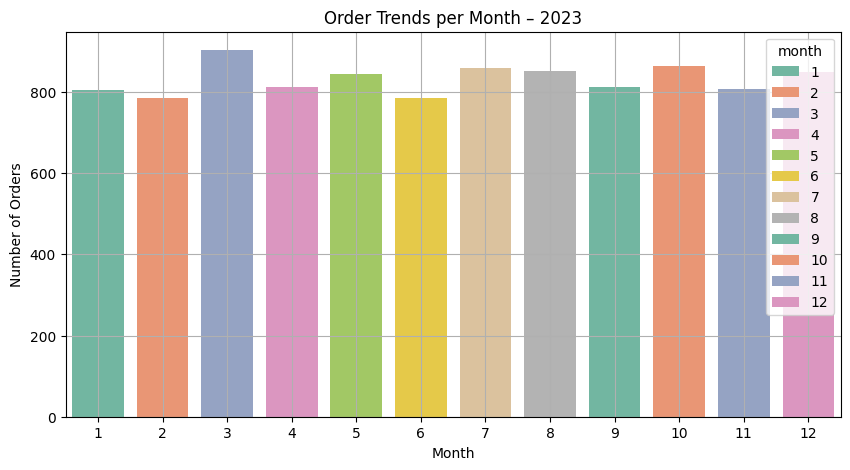

In [70]:
df_2023 = final_df[final_df["year"] == 2023]

plt.figure(figsize=(10,5))
sns.barplot(
    data=df_2023.groupby("month")["order_id"].count().reset_index(),
    x="month",
    y="order_id",
    hue="month",
    palette="Set2"
)
plt.title("Order Trends per Month – 2023")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\3575827868.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


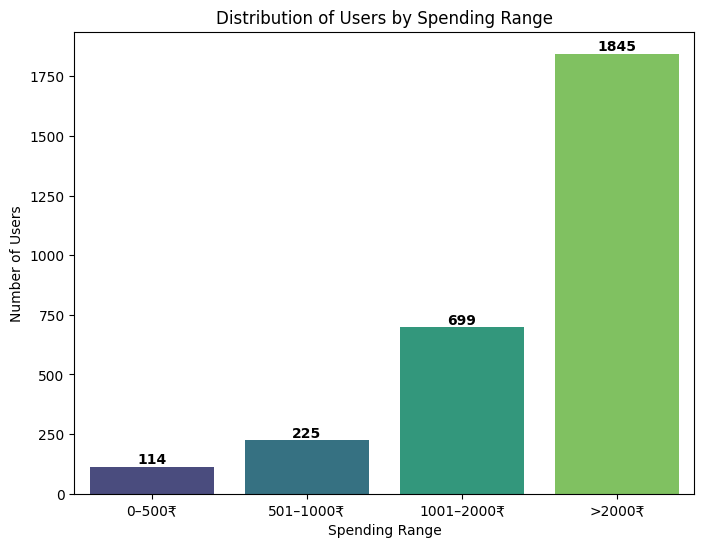

In [ ]:
# Number of user per spending range

# Total dépensé par utilisateur
user_spending = (
    final_df.groupby("user_id")["total_amount"]
    .sum()
    .reset_index(name="total_spent")
)

# Création de tranches de dépenses
bins = [0, 500, 1000, 2000, user_spending["total_spent"].max()]
labels = ["0–500₹", "501–1000₹", "1001–2000₹", ">2000₹"]

user_spending["spending_range"] = pd.cut(
    user_spending["total_spent"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Comptage par tranche
range_counts = (
    user_spending["spending_range"]
    .value_counts()
    .sort_index()
    .reset_index(name="count")
)

# Graphique général
plt.figure(figsize=(8,6))
sns.barplot(
    data=range_counts,
    x="spending_range",
    y="count",
    palette="viridis"
)

# Ajouter les valeurs
for i, v in enumerate(range_counts["count"]):
    plt.text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

plt.title("Distribution of Users by Spending Range")
plt.xlabel("Spending Range")
plt.ylabel("Number of Users")
plt.show()

In [173]:
restaurant_stats = (
    final_df.groupby("restaurant_id")
    .agg(
        avg_order_value=("total_amount", "mean"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)
restaurant_stats[restaurant_stats['avg_order_value'] == restaurant_stats['avg_order_value'].max()]

,restaurant_id,avg_order_value,total_orders
18,19,1126.52,26


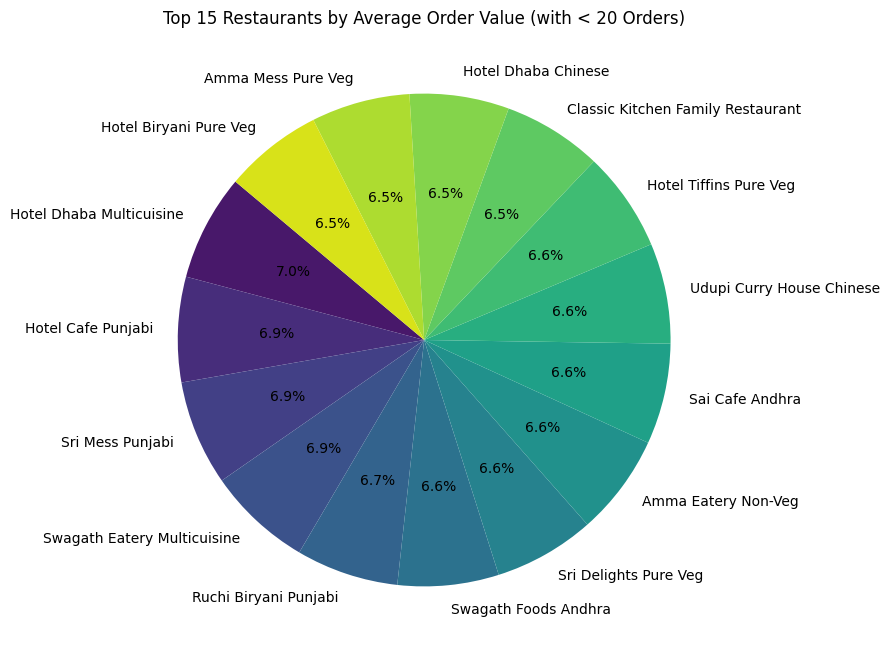

In [ ]:
# Calcul des stats par restaurant
restaurant_stats = (
    final_df.groupby("restaurant_id")
    .agg(
        avg_order_value=("total_amount", "mean"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

# Filtrer restaurants avec moins de 20 commandes
filtered_restaurants = restaurant_stats[restaurant_stats["total_orders"] < 20]

# Ajouter les noms des restaurants
filtered_restaurants = filtered_restaurants.merge(
    final_df[["restaurant_id", "restaurant_name"]].drop_duplicates(),
    on="restaurant_id",
    how="left"
)

# Top 5 par average order value
top5_restaurants = filtered_restaurants.sort_values(
    "avg_order_value", ascending=False
).head(15)

# Graphique camembert
plt.figure(figsize=(8,8))
plt.pie(
    top5_restaurants["avg_order_value"],
    labels=top5_restaurants["restaurant_name"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", 15)
)

plt.title("Top 15 Restaurants by Average Order Value (with < 20 Orders)")
plt.show()

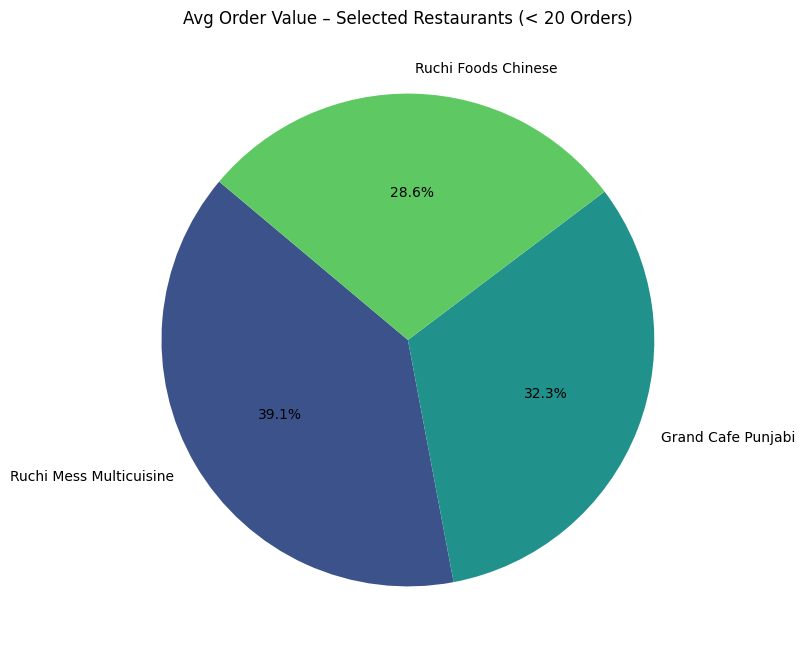

In [ ]:

# create pie chart for selected restaurants with less than 20 orders

# Liste des restaurants à analyser
selected_names = [
    "Grand Cafe Punjabi",
    "Grand Restaurant South Indian",
    "Ruchi Mess Multicuisine",
    "Ruchi Foods Chinese"
]

# Calcul des stats
restaurant_stats = (
    final_df.groupby("restaurant_id")
    .agg(
        avg_order_value=("total_amount", "mean"),
        total_orders=("order_id", "count")
    )
    .reset_index()
)

# Ajouter les noms
restaurant_stats = restaurant_stats.merge(
    final_df[["restaurant_id", "restaurant_name"]].drop_duplicates(),
    on="restaurant_id",
    how="left"
)

# Filtrer uniquement les restaurants demandés
filtered = restaurant_stats[
    restaurant_stats["restaurant_name"].isin(selected_names)
]

# Filtrer ceux avec moins de 20 commandes
filtered = filtered[filtered["total_orders"] < 20]

# Trier par avg_order_value et garder les 5 (ou moins si pas assez)
top_restaurants = filtered.sort_values(
    "avg_order_value", ascending=False
).head(5)

# Graphique camembert
plt.figure(figsize=(8,8))
plt.pie(
    top_restaurants["avg_order_value"],
    labels=top_restaurants["restaurant_name"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", len(top_restaurants))
)

plt.title("Avg Order Value – Selected Restaurants (< 20 Orders)")
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\2599839080.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


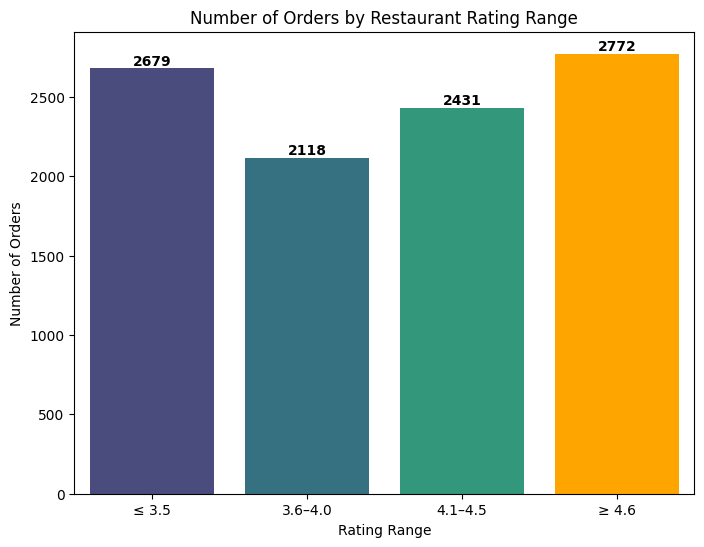

In [ ]:
# Comparison of Orders by Rating Category

# Définir les tranches de rating
bins = [0, 3.5, 4.0, 4.5, 5.0]
labels = ["≤ 3.5", "3.6–4.0", "4.1–4.5", "≥ 4.6"]

final_df["rating_range"] = pd.cut(
    final_df["rating"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Compter les commandes par tranche
rating_order_counts = (
    final_df.groupby("rating_range")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

# Graphique général
plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=rating_order_counts,
    x="rating_range",
    y="order_count",
    palette="viridis"
)

# Ajouter les valeurs sur les barres
for i, v in enumerate(rating_order_counts["order_count"]):
    plt.text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

# Mettre en évidence la barre ≥ 4.5
highlight_index = rating_order_counts.index[rating_order_counts["rating_range"] == "≥ 4.6"][0]
ax.patches[highlight_index].set_facecolor("orange")

plt.title("Number of Orders by Restaurant Rating Range")
plt.xlabel("Rating Range")
plt.ylabel("Number of Orders")
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\2088994046.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


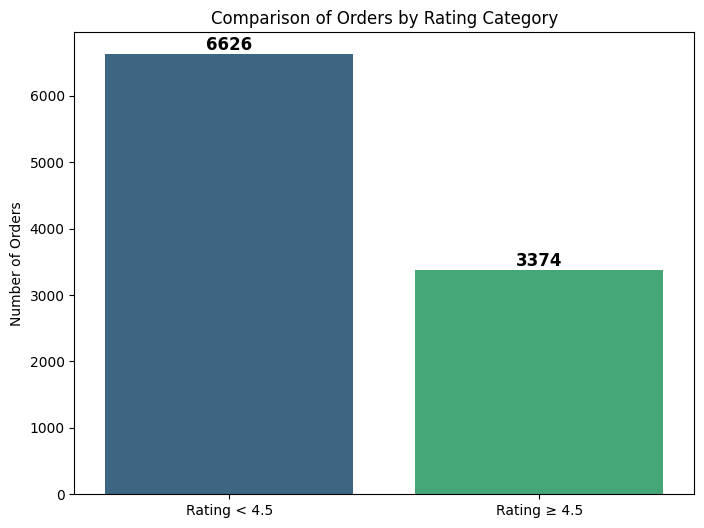

In [ ]:
# Comparison of Orders by Rating Category

# Nombre de commandes rating >= 4.5
high_rated_orders = final_df[final_df["rating"] >= 4.5]["order_id"].nunique()

# Nombre de commandes rating < 4.5
low_rated_orders = final_df[final_df["rating"] < 4.5]["order_id"].nunique()

# Préparer les données
labels = ["Rating < 4.5", "Rating ≥ 4.5"]
values = [low_rated_orders, high_rated_orders]

plt.figure(figsize=(8,6))
ax = sns.barplot(
    x=labels,
    y=values,
    palette="viridis"
)

# Ajouter les valeurs sur les barres
for i, v in enumerate(values):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.title("Comparison of Orders by Rating Category")
plt.ylabel("Number of Orders")
plt.xlabel("")
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\391172036.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


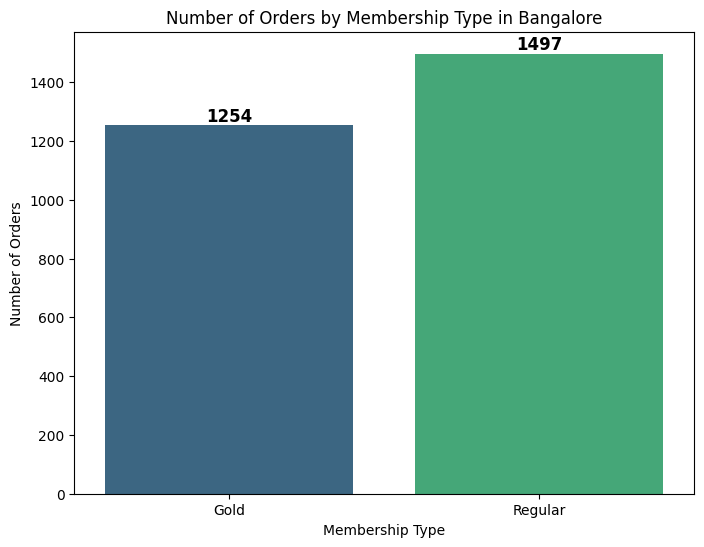

In [ ]:
# Comparison of Orders by Membership Type in Top Revenue City


# Compute total revenue per city
city_revenue = (
    final_df.groupby("city")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

# Identify the city with the highest total revenue
top_city = city_revenue.sort_values("total_revenue", ascending=False).iloc[0]["city"]

# Filter only the rows corresponding to the top revenue city
df_top_city = final_df[final_df["city"] == top_city]

# Count the number of orders per membership type in that city
membership_counts = (
    df_top_city.groupby("membership")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

# Plot the results
plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=membership_counts,
    x="membership",
    y="num_orders",
    palette="viridis"
)

# Add values on top of each bar
for i, v in enumerate(membership_counts["num_orders"]):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.title(f"Number of Orders by Membership Type in {top_city}")
plt.ylabel("Number of Orders")
plt.xlabel("Membership Type")
plt.show()

### User behavior patterns

In [73]:
final_df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating,year,month
0,1,2508,450,2023-02-18,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2,2023,2
1,2,2693,309,2023-01-18,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5,2023,1
2,3,2084,107,2023-07-15,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0,2023,7
3,4,319,224,2023-10-04,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8,2023,10
4,5,1064,293,2023-12-25,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0,2023,12


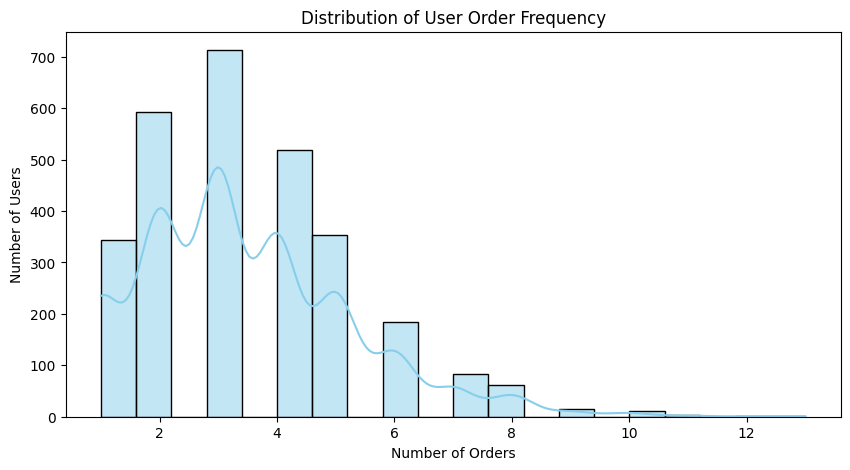

In [74]:
user_freq = (
    final_df.groupby("user_id")["order_id"]
    .count()
    .reset_index(name="order_count")
)

plt.figure(figsize=(10,5))
sns.histplot(user_freq["order_count"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of User Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Users")
plt.show()

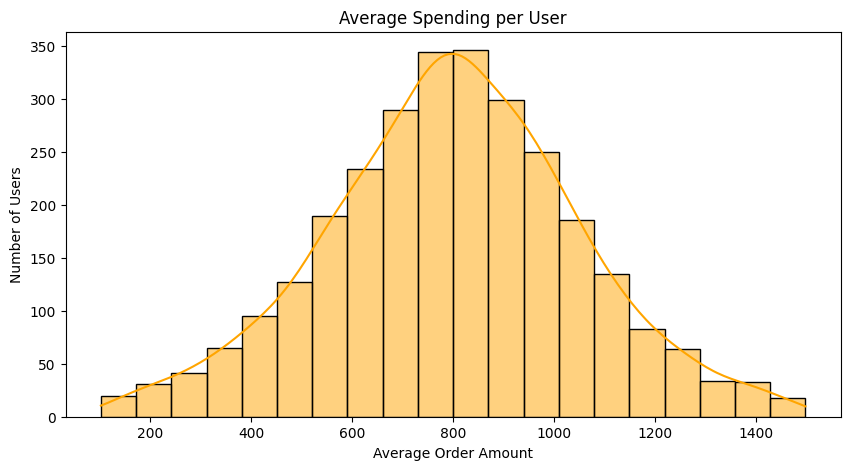

In [75]:
user_spending = (
    final_df.groupby("user_id")["total_amount"]
    .mean()
    .reset_index(name="avg_spending")
)

plt.figure(figsize=(10,5))
sns.histplot(user_spending["avg_spending"], bins=20, kde=True, color="orange")
plt.title("Average Spending per User")
plt.xlabel("Average Order Amount")
plt.ylabel("Number of Users")
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\1123805682.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


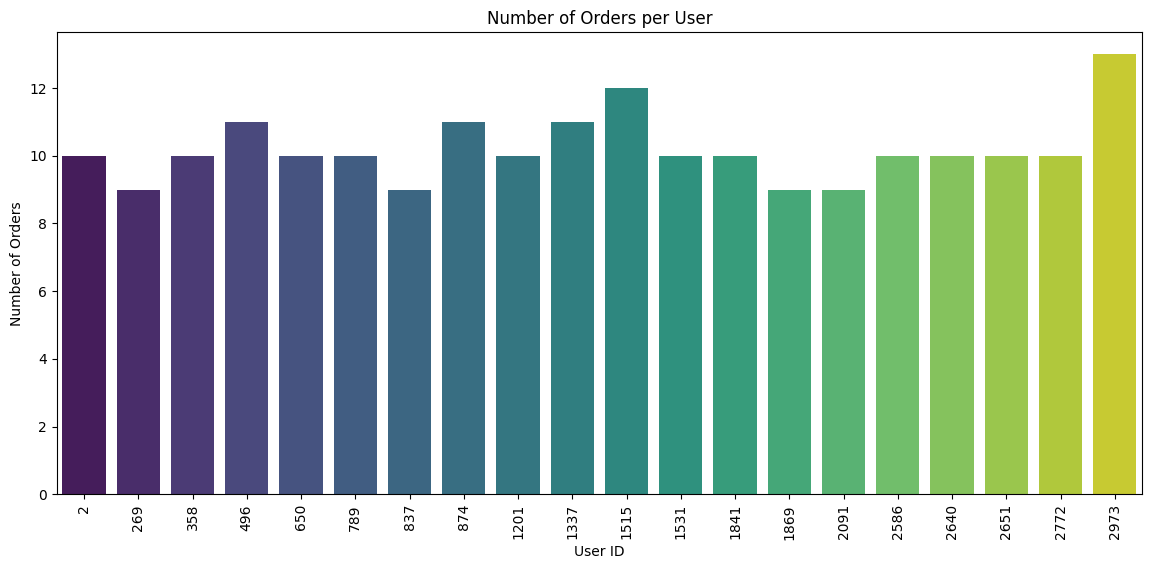

In [ ]:

# compute number of orders per user and plot
user_orders = (
    final_df.groupby("user_id")["order_id"]
    .count()
    .reset_index(name="order_count")
    .sort_values(by="order_count", ascending=False)
    .head(20)
)

plt.figure(figsize=(14,6))
sns.barplot(
    data=user_orders,
    x="user_id",
    y="order_count",
    palette="viridis"
)

plt.title("Number of Orders per User")
plt.xlabel("User ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)  # utile si beaucoup d'utilisateurs
plt.show()

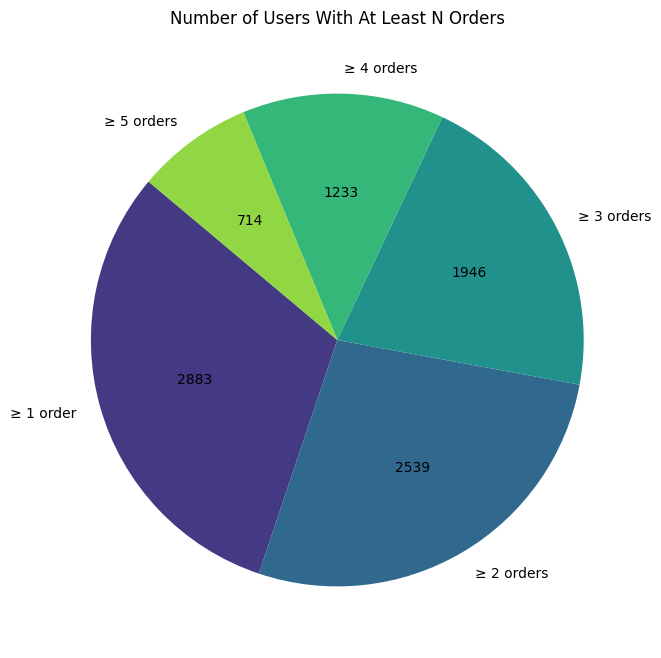

In [ ]:
# Count number of orders per user
user_order_counts = (
    final_df.groupby("user_id")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

# Compute number of users with at least N orders
at_least_counts = {
    "≥ 1 order": (user_order_counts["num_orders"] >= 1).sum(),
    "≥ 2 orders": (user_order_counts["num_orders"] >= 2).sum(),
    "≥ 3 orders": (user_order_counts["num_orders"] >= 3).sum(),
    "≥ 4 orders": (user_order_counts["num_orders"] >= 4).sum(),
    "≥ 5 orders": (user_order_counts["num_orders"] >= 5).sum(),
}

labels = list(at_least_counts.keys())
values = list(at_least_counts.values())

# Pie chart with raw numbers
plt.figure(figsize=(8,8))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f"{int(round(pct/100 * sum(values)))}",
    startangle=140,
    colors=sns.color_palette("viridis", len(values))
)

plt.title("Number of Users With At Least N Orders")
plt.show()

### City-wise and cuisine-wise performance

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\2880289682.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


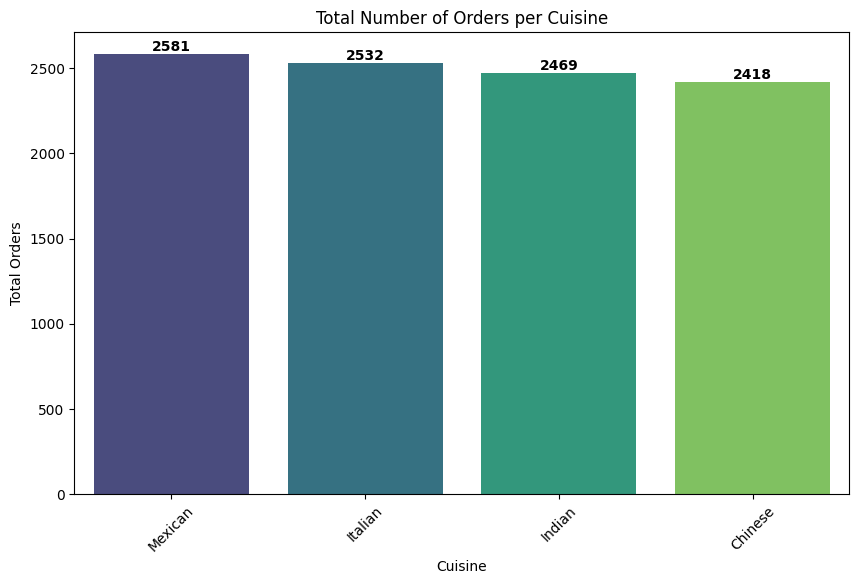

In [ ]:
# Compute total number of orders per cuisine
cuisine_stats = (
    final_df.groupby("cuisine")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

# Sort cuisines by total orders (optional but cleaner)
cuisine_stats = cuisine_stats.sort_values("total_orders", ascending=False)

# Bar chart
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=cuisine_stats,
    x="cuisine",
    y="total_orders",
    palette="viridis"
)

# Add values on top of each bar
for i, v in enumerate(cuisine_stats["total_orders"]):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Total Number of Orders per Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

### Membership impact (Gold vs Regular)

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\1733442160.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


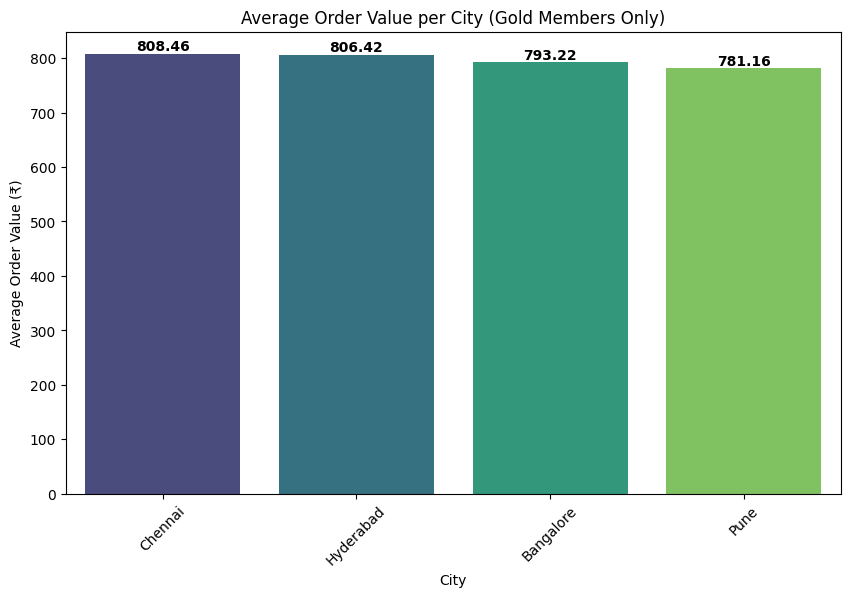

In [ ]:
# compute average order value per city for Gold members and plot

# Filter only Gold members
gold_df = final_df[final_df["membership"] == "Gold"]

# Compute average order value per city
city_stats_gold = (
    gold_df.groupby("city")["total_amount"]
    .mean()
    .reset_index(name="avg_order_value")
)

# Sort cities by average order value
city_stats_gold = city_stats_gold.sort_values("avg_order_value", ascending=False)

# Bar chart
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=city_stats_gold,
    x="city",
    y="avg_order_value",
    palette="viridis"
)

# Add values on top of each bar
for i, v in enumerate(city_stats_gold["avg_order_value"]):
    plt.text(i, v, str(round(v, 2)), ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Average Order Value per City (Gold Members Only)")
plt.xlabel("City")
plt.ylabel("Average Order Value (₹)")
plt.xticks(rotation=45)
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\3449799871.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


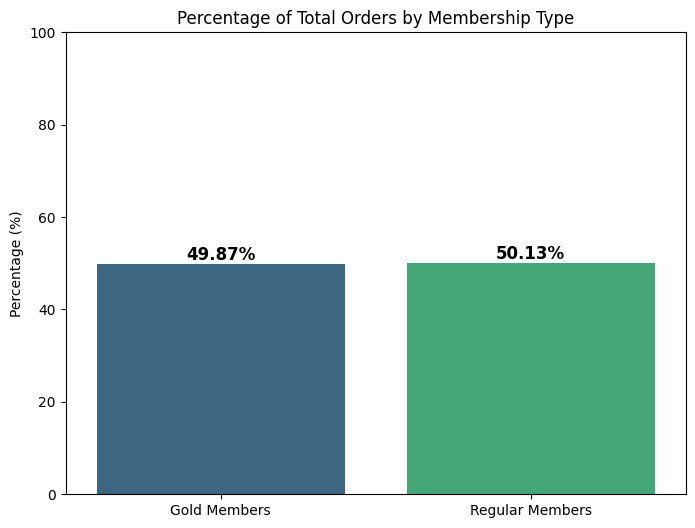

In [ ]:
# Total number of orders
total_orders = final_df["order_id"].nunique()

# Number of orders placed by Gold members
gold_orders = final_df[final_df["membership"] == "Gold"]["order_id"].nunique()

# Number of orders placed by Regular members
regular_orders = final_df[final_df["membership"] == "Regular"]["order_id"].nunique()

# Compute percentages
percentage_gold = round((gold_orders / total_orders) * 100, 2)
percentage_regular = round((regular_orders / total_orders) * 100, 2)

# Prepare data for the bar chart
labels = ["Gold Members", "Regular Members"]
values = [percentage_gold, percentage_regular]

# Plot
plt.figure(figsize=(8,6))
ax = sns.barplot(
    x=labels,
    y=values,
    palette="viridis"
)

# Add percentage labels on top of each bar
for i, v in enumerate(values):
    plt.text(i, v, f"{v}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Percentage of Total Orders by Membership Type")
plt.ylabel("Percentage (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.show()

In [156]:
combo_revenue = (
    final_df.groupby(["membership", "cuisine"])["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)
combo_revenue.head()

,membership,cuisine,total_revenue
0,Gold,Chinese,977713.74
1,Gold,Indian,979312.31
2,Gold,Italian,1005779.05
3,Gold,Mexican,1012559.79
4,Regular,Chinese,952790.91


In [157]:
top_combo = combo_revenue.sort_values(
    "total_revenue", ascending=False
).head(5)
top_combo.head()

,membership,cuisine,total_revenue
7,Regular,Mexican,1072943.30
6,Regular,Italian,1018424.75
3,Gold,Mexican,1012559.79
2,Gold,Italian,1005779.05
5,Regular,Indian,992100.27


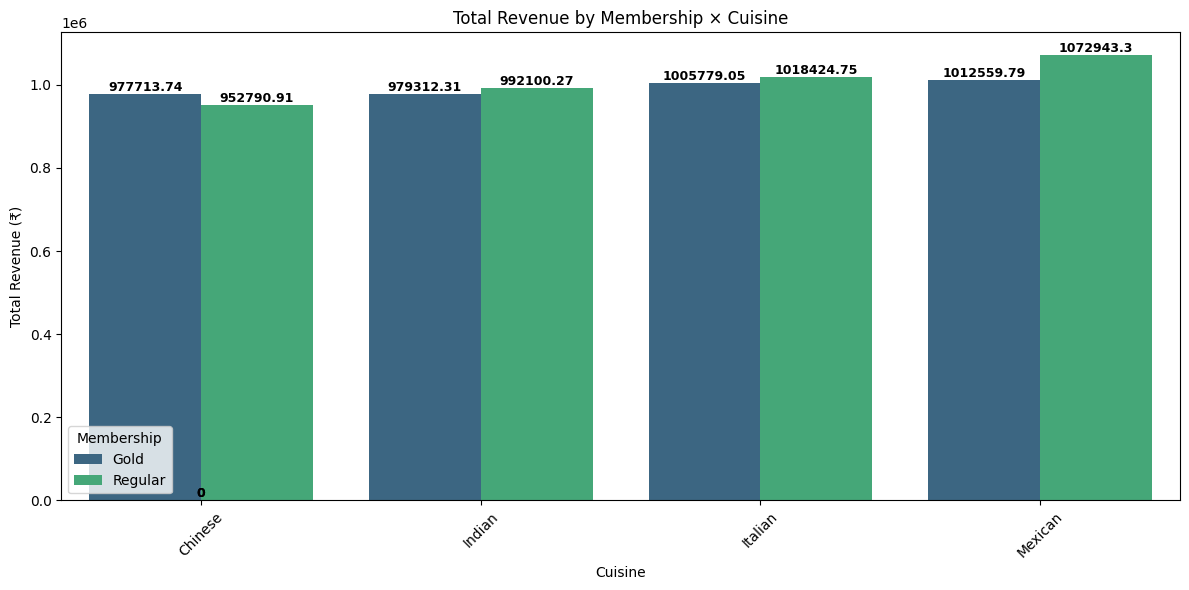

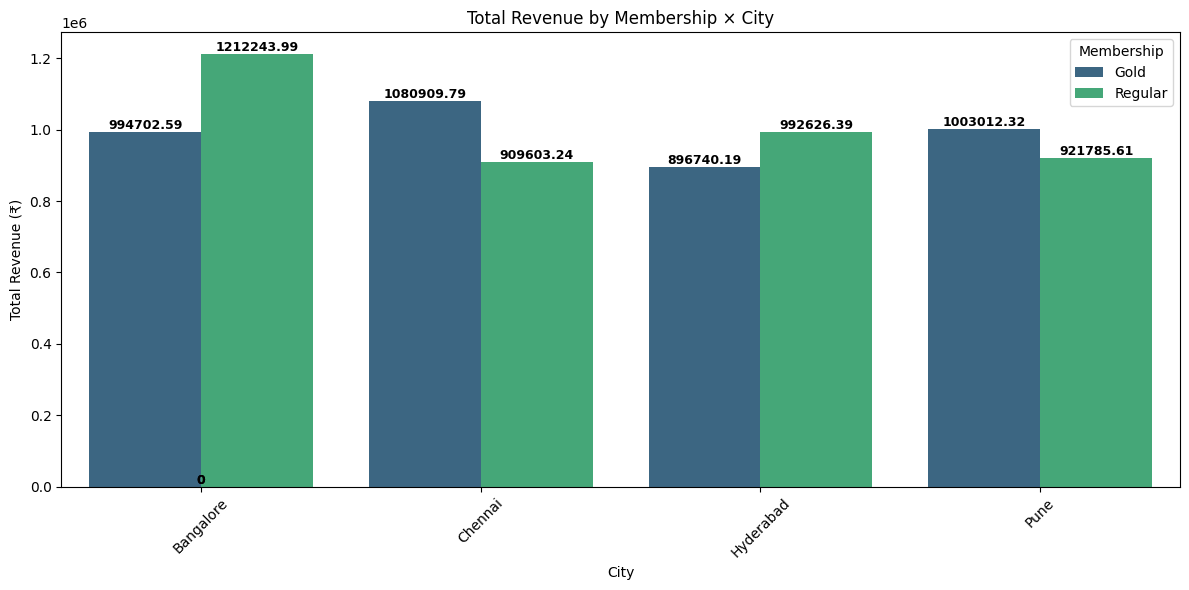

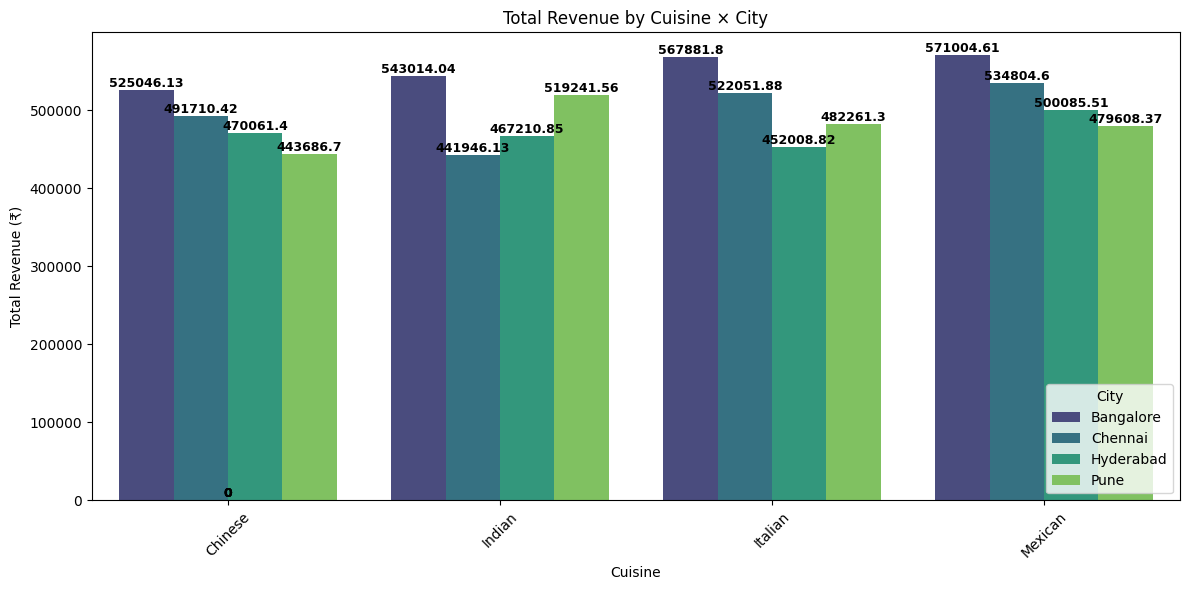

In [ ]:
# ============================
# 1. Membership × Cuisine
# ============================

combo_mc = (
    final_df.groupby(["membership", "cuisine"])["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=combo_mc,
    x="cuisine",
    y="total_revenue",
    hue="membership",
    palette="viridis"
)

# Add numbers on bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        str(round(height, 2)),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Revenue by Membership × Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.legend(title="Membership")
plt.tight_layout()
plt.show()


# ============================
# 2. Membership × City
# ============================

combo_mc2 = (
    final_df.groupby(["membership", "city"])["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=combo_mc2,
    x="city",
    y="total_revenue",
    hue="membership",
    palette="viridis"
)

# Add numbers on bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        str(round(height, 2)),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Revenue by Membership × City")
plt.xlabel("City")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.legend(title="Membership")
plt.tight_layout()
plt.show()


# ============================
# 3. Cuisine × City
# ============================

combo_cc = (
    final_df.groupby(["cuisine", "city"])["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=combo_cc,
    x="cuisine",
    y="total_revenue",
    hue="city",
    palette="viridis"
)

# Add numbers on bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        str(round(height, 2)),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Revenue by Cuisine × City")
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.legend(title="City")
plt.tight_layout()
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\2852056660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


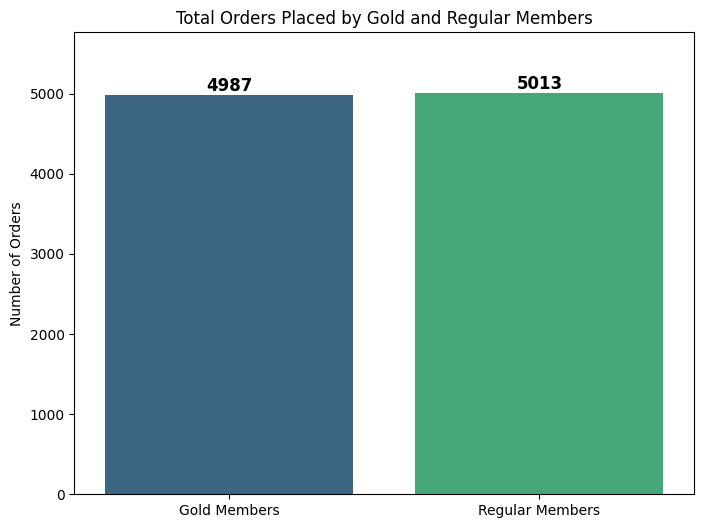

In [ ]:
# Count orders for each membership type
gold_orders = final_df[final_df["membership"] == "Gold"]["order_id"].nunique()
regular_orders = final_df[final_df["membership"] == "Regular"]["order_id"].nunique()

# Prepare data for the bar chart
labels = ["Gold Members", "Regular Members"]
values = [gold_orders, regular_orders]

# Plot
plt.figure(figsize=(8,6))
ax = sns.barplot(
    x=labels,
    y=values,
    palette="viridis"
)

# Add numbers on top of each bar
for i, v in enumerate(values):
    plt.text(
        i,
        v,
        str(v),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Total Orders Placed by Gold and Regular Members")
plt.ylabel("Number of Orders")
plt.xlabel("")
plt.ylim(0, max(values) * 1.15)
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\1583154287.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


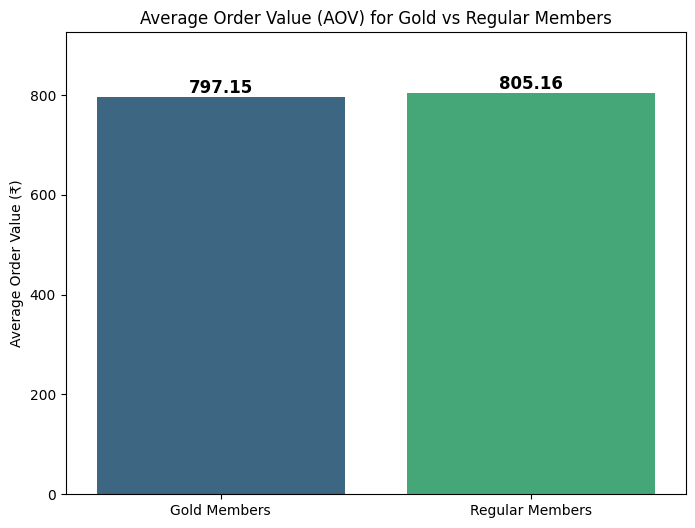

In [ ]:
# Compute AOV for Gold and Regular members
avg_gold_order_value = round(
    final_df[final_df["membership"] == "Gold"]["total_amount"].mean(), 2
)

avg_regular_order_value = round(
    final_df[final_df["membership"] == "Regular"]["total_amount"].mean(), 2
)

# Prepare data for the bar chart
labels = ["Gold Members", "Regular Members"]
values = [avg_gold_order_value, avg_regular_order_value]

# Plot
plt.figure(figsize=(8,6))
ax = sns.barplot(
    x=labels,
    y=values,
    palette="viridis"
)

# Add values on top of each bar
for i, v in enumerate(values):
    plt.text(
        i,
        v,
        str(v),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Average Order Value (AOV) for Gold vs Regular Members")
plt.ylabel("Average Order Value (₹)")
plt.xlabel("")
plt.ylim(0, max(values) * 1.15)
plt.show()

### Revenue distribution and seasonality

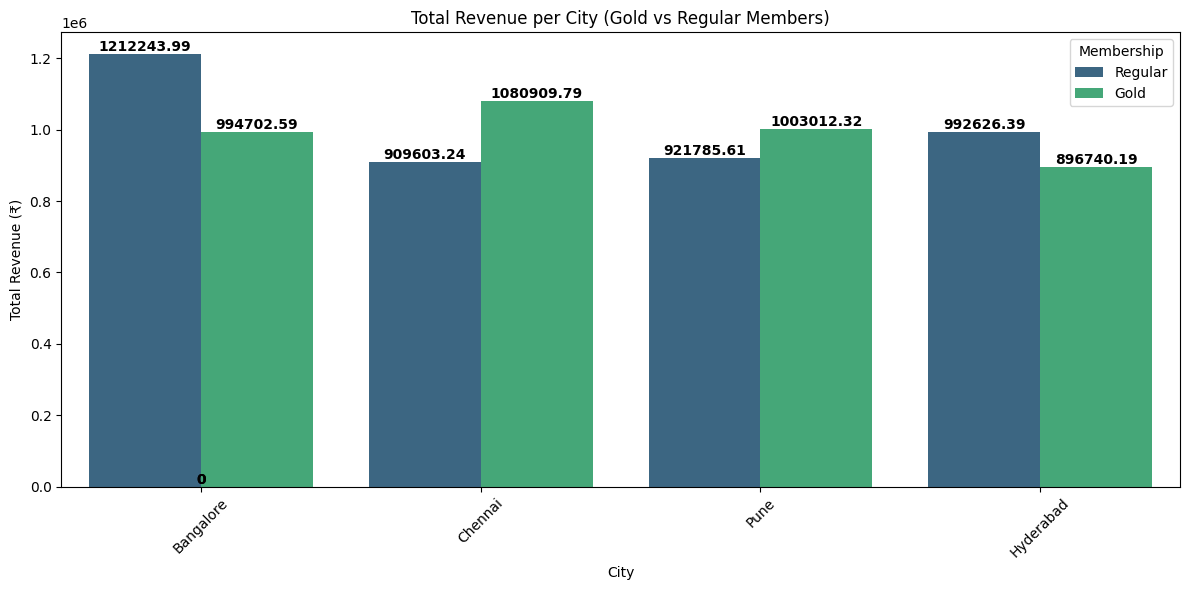

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter Gold and Regular members
gold_df = final_df[final_df["membership"] == "Gold"]
regular_df = final_df[final_df["membership"] == "Regular"]

# Compute total revenue per city for each membership type
city_revenue_gold = (
    gold_df.groupby("city")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)
city_revenue_gold["membership"] = "Gold"

city_revenue_regular = (
    regular_df.groupby("city")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)
city_revenue_regular["membership"] = "Regular"

# Combine both
city_revenue_all = pd.concat([city_revenue_gold, city_revenue_regular])

# Sort by revenue for readability
city_revenue_all = city_revenue_all.sort_values("total_revenue", ascending=False)

# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=city_revenue_all,
    x="city",
    y="total_revenue",
    hue="membership",
    palette="viridis"
)

# Add numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        str(round(height, 2)),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Total Revenue per City (Gold vs Regular Members)")
plt.xlabel("City")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.legend(title="Membership")
plt.tight_layout()
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\138033570.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


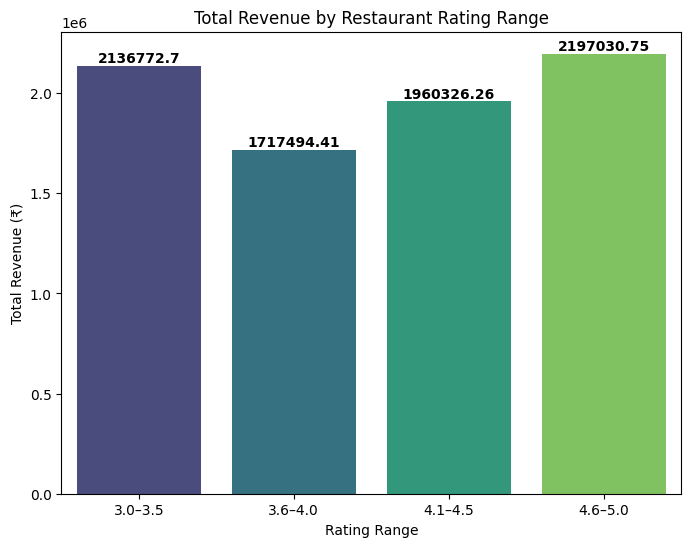

In [163]:
rating_bins = [3.0, 3.5, 4.0, 4.5, 5.0]
rating_labels = ["3.0–3.5", "3.6–4.0", "4.1–4.5", "4.6–5.0"]

final_df["rating_range"] = pd.cut(
    final_df["rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

rating_revenue = (
    final_df.groupby("rating_range")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

top_rating_range = rating_revenue.sort_values(
    "total_revenue", ascending=False
).head(1)

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=rating_revenue,
    x="rating_range",
    y="total_revenue",
    palette="viridis"
)

# Ajouter les valeurs sur les barres
for i, v in enumerate(rating_revenue["total_revenue"]):
    ax.text(
        i,
        v,
        str(round(v, 2)),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Total Revenue by Restaurant Rating Range")
plt.xlabel("Rating Range")
plt.ylabel("Total Revenue (₹)")
plt.show()


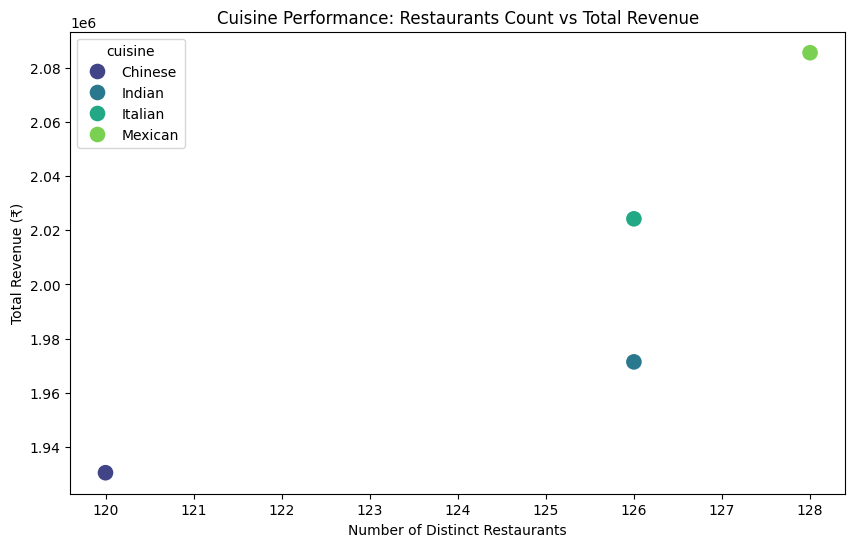

In [164]:
restaurants_per_cuisine = (
    final_df.groupby("cuisine")["restaurant_id"]
    .nunique()
    .reset_index(name="distinct_restaurants")
)

revenue_per_cuisine = (
    final_df.groupby("cuisine")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

cuisine_stats = restaurants_per_cuisine.merge(
    revenue_per_cuisine, on="cuisine"
)

cuisine_stats_sorted = cuisine_stats.sort_values(
    ["distinct_restaurants", "total_revenue"],
    ascending=[True, False]
)

cuisine_stats_sorted.head(1)


plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=cuisine_stats,
    x="distinct_restaurants",
    y="total_revenue",
    hue="cuisine",
    s=150,
    palette="viridis"
)

plt.title("Cuisine Performance: Restaurants Count vs Total Revenue")
plt.xlabel("Number of Distinct Restaurants")
plt.ylabel("Total Revenue (₹)")
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\3966023539.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


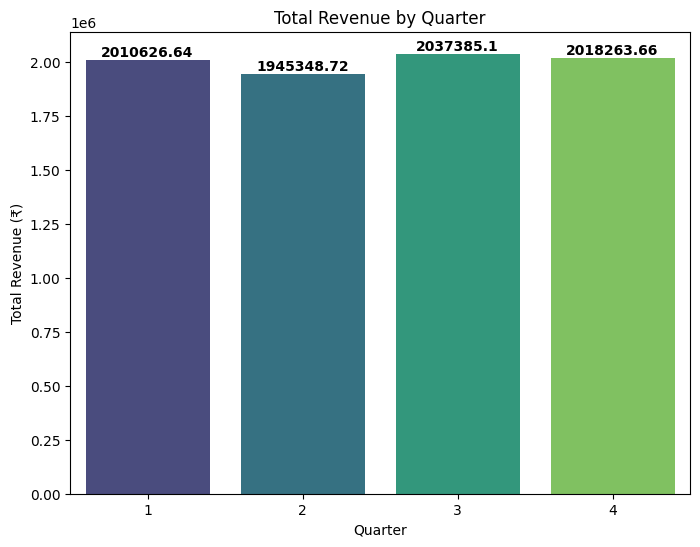

In [166]:
final_df["quarter"] = final_df["order_date"].dt.quarter
quarter_revenue = (
    final_df.groupby("quarter")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)
top_quarter = quarter_revenue.sort_values(
    "total_revenue", ascending=False
).head(1)


plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=quarter_revenue,
    x="quarter",
    y="total_revenue",
    palette="viridis"
)

# Ajouter les valeurs sur les barres
for i, v in enumerate(quarter_revenue["total_revenue"]):
    ax.text(
        i,
        v,
        str(round(v, 2)),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Total Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue (₹)")
plt.show()

C:\Users\noume\AppData\Local\Temp\ipykernel_26896\3571941750.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


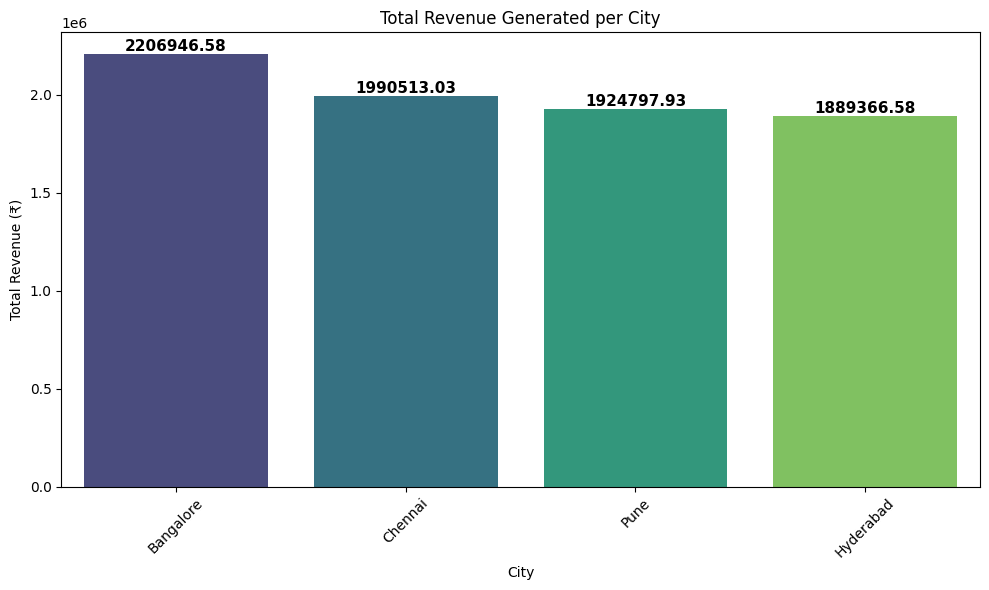

In [ ]:
# Compute total revenue for each city
city_revenue = (
    final_df.groupby("city")["total_amount"]
    .sum()
    .reset_index(name="total_revenue")
)

# Sort cities by revenue (optional but cleaner)
city_revenue = city_revenue.sort_values("total_revenue", ascending=False)

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=city_revenue,
    x="city",
    y="total_revenue",
    palette="viridis"
)

# Add numbers on top of each bar
for i, v in enumerate(city_revenue["total_revenue"]):
    plt.text(
        i,
        v,
        str(round(v, 2)),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Total Revenue Generated per City")
plt.ylabel("Total Revenue (₹)")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()